In [3]:
import pandas as pd
import os
from tqdm import tqdm

# Input paths
SOURCE_CSV = "/home/yuyao/methane_train/csvs/merged_file.csv" 
OUT_CSV = "./CM_L89_L2SR_gee.csv"

# Directory mapping
DIRS = {
    "t0": "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_L89_L2SR_by_gee",
    "m7": "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_L89_-7_L2SR_by_gee",
    "hist": "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_L89_90360_L2SR_by_gee"
}

def build_file_map(directory):
    """Creates a mapping of plume_id -> [list of full paths]"""
    file_map = {}
    if not os.path.exists(directory):
        print(f"Warning: Directory not found: {directory}")
        return file_map
    
    # os.scandir is the fastest way to list files
    with os.scandir(directory) as it:
        for entry in it:
            if entry.is_file() and entry.name.endswith(".tif"):
                # Extract plume_id: assumes plume_id is the string before the first underscore 
                # or based on your example 'tan...-A'
                if "_minus90" in entry.name:
                    pid = entry.name.split('_l89')[0].split('_minus90')[0]
                elif "_minus360" in entry.name:
                    pid = entry.name.split('_l89')[0].split('_minus360')[0]
                else:
                    pid = entry.name.split('_l89')[0]
                # pid = entry.name.split('_l89')[0].split('_minus90')[0] or entry.name.split('_l89')[0].split('_minus360')[0]
                if pid not in file_map:
                    file_map[pid] = []
                file_map[pid].append(entry.path)
    return file_map

# 1. Pre-scan all directories (This is the speed secret)
print("Scanning directories...")
map_t0 = build_file_map(DIRS["t0"])
map_m7 = build_file_map(DIRS["m7"])
map_hist = build_file_map(DIRS["hist"])

# 2. Load source and match in memory
df = pd.read_csv(SOURCE_CSV)
new_data = []

print("Matching plumes...")
for pid in tqdm(df['plume_id'].unique()):
    # Lookup t0
    path0 = map_t0.get(pid, [""])[0]
    
    # Lookup m7
    path7 = map_m7.get(pid, [""])[0]
    
    # Lookup hist (90 and 360)
    hist_files = map_hist.get(pid, [])
    path90 = ""
    path360 = ""
    
    for f in hist_files:
        print(f)
        # exit()
        if "minus90_" in f:
            path90 = f
        elif "minus360_" in f:
            # Assumes the other file in the 90360 folder is the 360 one
            path360 = f

    new_data.append({
        "plume_id": pid,
        "l89_path": path0,
        "l89_-7_path": path7,
        "l89_pre_path": path90,
        "l89_pre_pre_path": path360,
        "std_ok": 0
    })

# 3. Save
out_df = pd.DataFrame(new_data)
os.makedirs(os.path.dirname(OUT_CSV), exist_ok=True)
out_df.to_csv(OUT_CSV, index=False)

print(f"Done. Successfully matched {len(out_df)} plumes.")

Scanning directories...
Matching plumes...


100%|██████████| 24470/24470 [00:00<00:00, 546798.47it/s]

/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_L89_90360_L2SR_by_gee/GAO20191022t151126p0000-D_minus360_l89_sr_LANDSAT_8_20181028T172713Z.tif
/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_L89_90360_L2SR_by_gee/GAO20191022t151126p0000-D_minus90_l89_sr_LANDSAT_8_20190727T172720Z.tif
/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_L89_90360_L2SR_by_gee/GAO20191022t151126p0000-F_minus90_l89_sr_LANDSAT_8_20190727T172720Z.tif
/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_L89_90360_L2SR_by_gee/GAO20191022t151126p0000-F_minus360_l89_sr_LANDSAT_8_20181028T172713Z.tif
/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_L89_90360_L2SR_by_gee/GAO20191022t151126p0000-G_minus90_l89_sr_LANDSAT_8_20190727T172720Z.tif
/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_l89_L2SR/raw_data_dir_

In [11]:
df = pd.read_csv("./CM_L89_L2SR_gee.csv")
df.dropna(subset=['l89_path', 'l89_-7_path', 'l89_pre_path', 'l89_pre_pre_path'], inplace=True)
print(len(df))
df.to_csv("./CM_L89_L2SR_gee.csv", index=False)

2623


In [ ]:
# crop to 512x512 with NaN handling
import os
import time
import threading
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
import contextlib
from collections import Counter, deque

import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
from rasterio.transform import from_origin
import tifffile
from tqdm import tqdm

# =========================
# Config (L89 Specific)
# =========================
CM_CSV  = "./CM_L89_L2SR_gee.csv"
OUT_CSV = "./CM_L89_L2SR_std512.csv"

# Target directory for the 512x512 crops
OUT_ROOT = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/L89_-790360_512std"

WINDOW_SIZE = 512
MAX_WORKERS = 12
FLUSH_EVERY_SEC = 60

# Requirements: t0 and m7/m8 are usually the priority
REQUIRE_T0 = True
REQUIRE_M7 = True 

# =========================
# Utils
# =========================
def debug(msg: str) -> None:
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{ts}][pid:{os.getpid()}][tid:{threading.get_ident()}] {msg}", flush=True)

def safe_mkdir(p: str) -> None:
    os.makedirs(p, exist_ok=True)

@contextlib.contextmanager
def suppress_stderr():
    with open(os.devnull, "w") as devnull:
        with contextlib.redirect_stderr(devnull):
            yield

# =========================
# Array helpers -> BHW with NaN handling
# =========================
def to_bhw_l89(arr: np.ndarray) -> np.ndarray:
    """
    Standardizes to (B, H, W). 
    Landsat 8/9 SR from GEE typically comes as 7 bands.
    """
    if arr.ndim == 2:
        return arr[None, :, :]
    
    # If HWC (7 bands at end), transpose to CHW
    if arr.shape[-1] == 7 and arr.shape[0] != 7:
        return np.transpose(arr, (2, 0, 1))
    return arr

def center_crop_or_pad_bhw(bhw: np.ndarray, out_size=512):
    B, H, W = bhw.shape
    
    # If exact size
    if H == out_size and W == out_size:
        return bhw, (0, 0), "noop"

    # Create output array filled with NaNs (since we are using float32)
    out = np.full((B, out_size, out_size), np.nan, dtype=np.float32)
    
    if H < out_size or W < out_size:
        y0 = max(0, (out_size - H) // 2)
        x0 = max(0, (out_size - W) // 2)
        # Only copy what we have
        h_copy = min(H, out_size)
        w_copy = min(W, out_size)
        out[:, y0:y0+h_copy, x0:x0+w_copy] = bhw[:, :h_copy, :w_copy]
        return out, (x0, y0), f"pad_center {H}x{W}"

    # Larger -> center crop
    y0 = (H - out_size) // 2
    x0 = (W - out_size) // 2
    out = bhw[:, y0:y0+out_size, x0:x0+out_size]
    return out, (x0, y0), f"crop_center {H}x{W}"

# =========================
# Core Processing Logic
# =========================
def std_to_512_l89(in_path: str, out_path: str, tag: str, bug_list: list):
    if not (isinstance(in_path, str) and len(in_path) > 0 and os.path.exists(in_path)):
        return False, f"{tag}_missing"

    if os.path.exists(out_path) and os.path.getsize(out_path) > 0:
        return True, "skipped_exists"

    try:
        with rasterio.open(in_path) as ds:
            # Try to read with window to save memory
            h, w = ds.height, ds.width
            if h >= WINDOW_SIZE and w >= WINDOW_SIZE:
                col0 = (w - WINDOW_SIZE) // 2
                row0 = (h - WINDOW_SIZE) // 2
                win = Window(col0, row0, WINDOW_SIZE, WINDOW_SIZE)
                arr = ds.read(window=win)
            else:
                arr = ds.read()
            
            # Convert to float32 immediately to support NaNs
            bhw = arr.astype(np.float32)
            
            # ✅ IMPORTANT: Handle '0' as NoData for Landsat
            # We assume if all bands are 0 at a pixel, it is a fill value
            nodata_mask = (np.sum(bhw, axis=0) == 0)
            for b in range(bhw.shape[0]):
                bhw[b, nodata_mask] = np.nan

            bhw = to_bhw_l89(bhw)
            bhw2, _, note = center_crop_or_pad_bhw(bhw, out_size=WINDOW_SIZE)

            # Write as multi-band GeoTIFF
            write_gdal_multiband_tif(out_path, bhw2)
            return True, note
            
    except Exception as e:
        bug_list.append(f"{tag}_err: {str(e)}")
        return False, f"{tag}_fail"

def write_gdal_multiband_tif(out_path: str, bhw: np.ndarray):
    B, H, W = bhw.shape
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    
    profile = {
        "driver": "GTiff",
        "height": H, "width": W, "count": B,
        "dtype": "float32",
        "transform": from_origin(0, 0, 1, 1),
        "compress": "deflate",
        "predictor": 2, # Standard for floating point
        "tiled": True,
        "BIGTIFF": "IF_SAFER",
    }
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(bhw)

# =========================
# Worker
# =========================
def process_one_row_l89(row: dict):
    plume_id = str(row.get("plume_id", "")).strip()
    
    # Mapping the paths based on your L89 column names
    p0   = row.get("l89_path", "")
    pm7  = row.get("l89_-7_path", "")
    pm90 = row.get("l89_pre_path", "")
    pm360= row.get("l89_pre_pre_path", "")

    out_dir = os.path.join(OUT_ROOT, plume_id)
    safe_mkdir(out_dir)

    outputs = {
        "l89_0_std_512": os.path.join(out_dir, "l89_0_std_512.tif"),
        "l89_-7_std_512": os.path.join(out_dir, "l89_-7_std_512.tif"),
        "l89_-90_std_512": os.path.join(out_dir, "l89_-90_std_512.tif"),
        "l89_-360_std_512": os.path.join(out_dir, "l89_-360_std_512.tif")
    }

    bug = []
    # Process t0
    ok0, _ = std_to_512_l89(p0, outputs["l89_0_std_512"], "t0", bug)
    if REQUIRE_T0 and not ok0:
        return plume_id, {"std_ok": 0, "std_reason": "t0_fail", "bug": "; ".join(bug)}

    # Process others
    ok7, _ = std_to_512_l89(pm7, outputs["l89_-7_std_512"], "m7", bug)
    if REQUIRE_M7 and not ok7:
        return plume_id, {"std_ok": 0, "std_reason": "m7_fail", "bug": "; ".join(bug)}

    ok90, _ = std_to_512_l89(pm90, outputs["l89_-90_std_512"], "m90", bug)
    ok360, _ = std_to_512_l89(pm360, outputs["l89_-360_std_512"], "m360", bug)

    return plume_id, {
        "std_ok": 1,
        "bug": "; ".join(bug),
        **outputs,
        "has_m90": int(ok90),
        "has_m360": int(ok360)
    }

# =========================
# Main Execution
# =========================
if __name__ == "__main__":
    debug(f"Starting L89 Preprocessing: {CM_CSV}")
    df = pd.read_csv(CM_CSV)
    
    # Initialize columns if not exist
    for c in ["std_ok", "bug", "l89_0_std_512", "l89_-7_std_512", "l89_-90_std_512", "l89_-360_std_512"]:
        if c not in df.columns: df[c] = ""

    work_df = df[df["std_ok"].astype(str) != "1"].copy()
    
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        futs = [ex.submit(process_one_row_l89, r.to_dict()) for _, r in work_df.iterrows()]
        for fut in tqdm(as_completed(futs), total=len(futs), desc="Processing L89"):
            pid, upd = fut.result()
            mask = (df["plume_id"].astype(str) == str(pid))
            for k, v in upd.items():
                df.loc[mask, k] = v
    
    df.to_csv(OUT_CSV, index=False)
    debug("Done.")

[2026-01-26 14:55:55][pid:934926][tid:123214885725248] Starting L89 Preprocessing: ./CM_L89_L2SR_gee.csv


Processing L89:  14%|█▍        | 365/2623 [00:00<00:05, 440.20it/s]/home/yuyao/anaconda3/envs/methane/lib/python3.13/site-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(
/home/yuyao/anaconda3/envs/methane/lib/python3.13/site-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore this matrix and save no geotransform without raising an error. This behavior is somewhat driver-specific.
  dataset = writer(
Processing L89:  16%|█▌        | 417/2623 [00:03<00:39, 55.33it/s] /home/yuyao/anaconda3/envs/methane/lib/python3.13/site-packages/rasterio/__init__.py:366: NotGeoreferencedWarning: The given matrix is equal to Affine.identity or its flipped counterpart. GDAL may ignore th

[2026-01-26 15:20:11][pid:934926][tid:123214885725248] Done.


In [14]:
import pandas as pd
import os
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import Affine
from pyproj import Transformer
from tqdm import tqdm

# =========================
# 配置 (根据你的环境修改)
# =========================
# 包含 plume_id, path_t0 (Landsat路径), latitude, longitude 的 CSV
SOURCE_CSV = '/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file.csv'

# 原始高分辨率航空掩膜的存储根目录
BASE_AIRBORNE_DIR = '/data2/yuyao/methane_emission/carbon_mapper_data_masks'

# 目标输出目录：生成的 30m 512x512 对齐掩膜
OUT_MASK_ROOT = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/plume_masks_l89_512'

TARGET_RES = 30  # Landsat 8/9 原生分辨率 (米)
TARGET_SIZE = 512

# =========================
# 核心处理函数
# =========================

def process_l89_mask(plume_id, center_lat, center_lon, ref_tif_path):
    """
    通过读取参考卫星图 (ref_tif_path) 的 CRS，将航空掩膜重投影并对齐。
    """
    # 定义输出路径
    dst_path = os.path.join(OUT_MASK_ROOT, plume_id, 'mask_30m_512.tif')
    os.makedirs(os.path.dirname(dst_path), exist_ok=True)

    # 定义输入掩膜路径
    input_tif = os.path.join(BASE_AIRBORNE_DIR, plume_id, 'plume.tif')

    # 检查必要文件是否存在
    if not os.path.exists(input_tif):
        return False, f"Source mask missing: {input_tif}"
    if not os.path.exists(ref_tif_path):
        return False, f"Reference Landsat missing: {ref_tif_path}"

    try:
        # 1. 动态获取 Landsat 卫星图的 CRS (如 EPSG:32613)
        with rasterio.open(ref_tif_path) as ref:
            target_crs = ref.crs
            # 如果参考图本身就是 512x512，我们可以直接复用它的 transform
            ref_transform = ref.transform
            ref_height, ref_width = ref.height, ref.width

        with rasterio.open(input_tif) as src:
            if src.height == 0 or src.width == 0:
                return False, "Empty source TIFF"

            # 2. 坐标转换：将 CSV 里的经纬度转为目标卫星图的投影坐标
            transformer = Transformer.from_crs("EPSG:4326", target_crs, always_xy=True)
            center_x, center_y = transformer.transform(center_lon, center_lat)

            # 3. 网格吸附 (Grid Snapping)
            # 确保 Mask 的像素中心与卫星图像素点完全重合
            center_x = round(center_x / TARGET_RES) * TARGET_RES
            center_y = round(center_y / TARGET_RES) * TARGET_RES

            # 4. 计算 512x512 窗口的左上角坐标
            top_left_x = center_x - (TARGET_SIZE // 2) * TARGET_RES
            top_left_y = center_y + (TARGET_SIZE // 2) * TARGET_RES
            
            # 构造新的仿射变换矩阵
            new_transform = Affine(TARGET_RES, 0, top_left_x, 0, -TARGET_RES, top_left_y)
            
            # 5. 准备输出阵列
            out_mask = np.zeros((1, TARGET_SIZE, TARGET_SIZE), dtype='uint8')

            # 6. 执行重投影 (使用最近邻插值保持标签纯净)
            reproject(
                source=rasterio.band(src, 1),
                destination=out_mask[0],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=new_transform,
                dst_crs=target_crs, # 关键：投影到卫星图的坐标系
                resampling=Resampling.nearest
            )

            # 7. 写入磁盘，保留所有地理信息
            profile = src.profile.copy()
            profile.update(
                driver='GTiff',
                transform=new_transform,
                crs=target_crs,
                width=TARGET_SIZE,
                height=TARGET_SIZE,
                count=1,
                dtype='uint8',
                compress='lzw',
                nodata=0
            )

            with rasterio.open(dst_path, 'w', **profile) as dst:
                dst.write(out_mask)
            
            return True, "Success"

    except Exception as e:
        return False, str(e)

# =========================
# 主程序
# =========================

if __name__ == "__main__":
    print(f"Loading source data from {SOURCE_CSV}...")
    df = pd.read_csv(SOURCE_CSV)
    
    # 确保 CSV 中包含必要的路径列，如果没有 path_t0 请根据实际列名修改
    # 假设你的列名叫 'path_t0'
    work_df = df[df['path_t0'].notna()].copy()
    
    print(f"Total plumes to process: {len(work_df)}")

    results = []
    for index, row in tqdm(work_df.iterrows(), total=len(work_df)):
        pid = row['plume_id']
        lat = row['plume_latitude']
        lon = row['plume_longitude']
        ref_path = row['path_t0'] # 卫星图路径
        
        # 排除已知的异常数据
        if pid == 'GAO20210515t145818p0000-1':
            continue
            
        success, msg = process_l89_mask(pid, lat, lon, ref_path)
        if not success:
            results.append({"plume_id": pid, "error": msg})

    # 输出错误日志
    if results:
        error_df = pd.DataFrame(results)
        error_df.to_csv('mask_gen_errors.csv', index=False)
        print(f"\nDone. Errors encountered: {len(results)}. See mask_gen_errors.csv")
    else:
        print("\nDone. All masks generated and aligned successfully.")

Loading source data from /data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file.csv...


FileNotFoundError: [Errno 2] No such file or directory: '/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file.csv'

------------------------------
Processing: GAO20191019t145209p0000-A
Target (CSV) Center: Lat 31.450855, Lon -101.75815
Original Mask Center:  (31.450462825474588, -101.75817853788152)
30m Resized Center:    (31.450756099416648, -101.75801067210334)
Shift from Target:     ~10.98m Lat, ~13.19m Lon


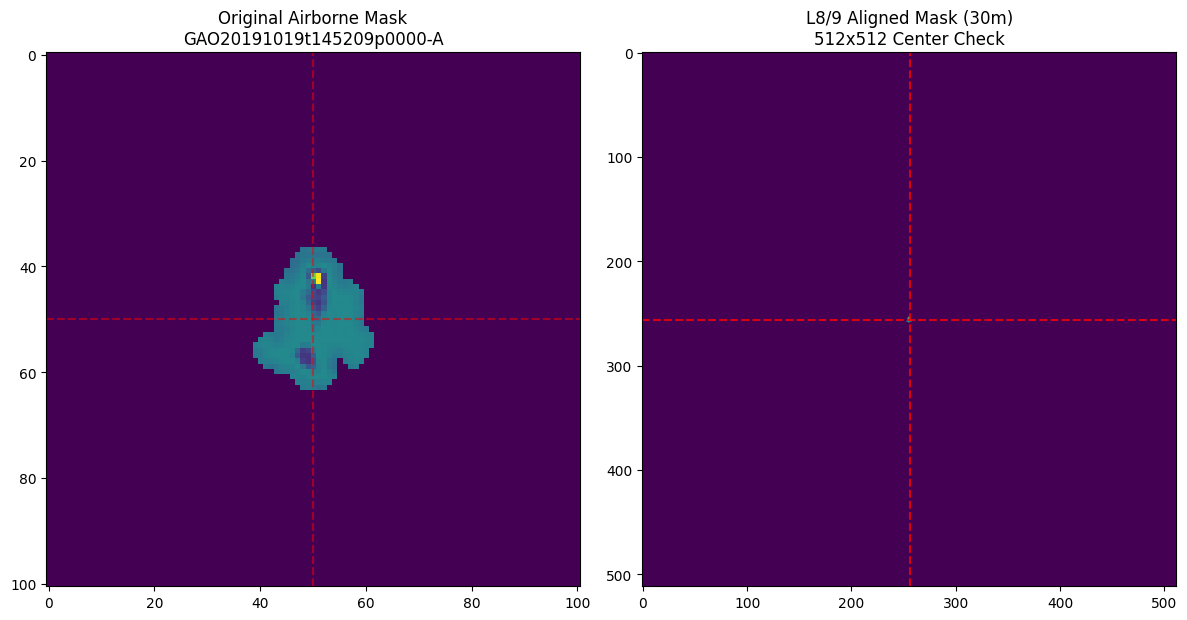

------------------------------
Processing: GAO20191019t151221p0000-A
Target (CSV) Center: Lat 31.4175117, Lon -102.16486
Original Mask Center:  (31.417698125944817, -102.16472639685834)
30m Resized Center:    (31.41740214048328, -102.16479839776854)
Shift from Target:     ~12.16m Lat, ~5.84m Lon


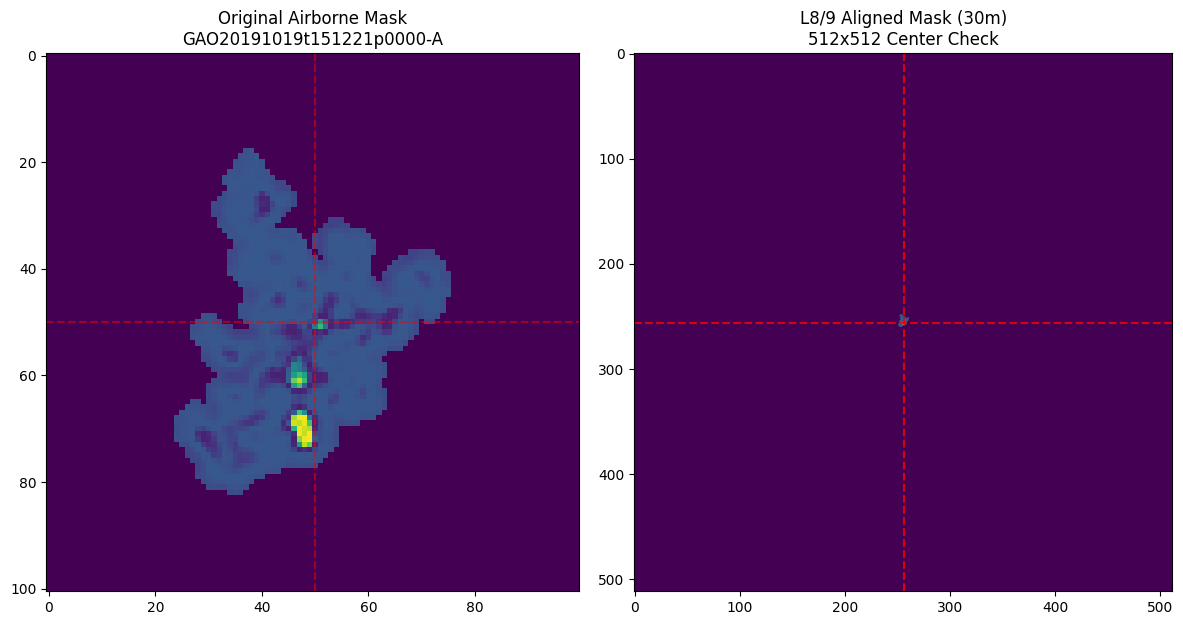

------------------------------
Processing: GAO20191019t151221p0000-B
Target (CSV) Center: Lat 31.410972, Lon -102.07123
Original Mask Center:  (31.41020192062003, -102.0720283179541)
30m Resized Center:    (31.410970007430798, -102.0713105211281)
Shift from Target:     ~0.22m Lat, ~7.63m Lon


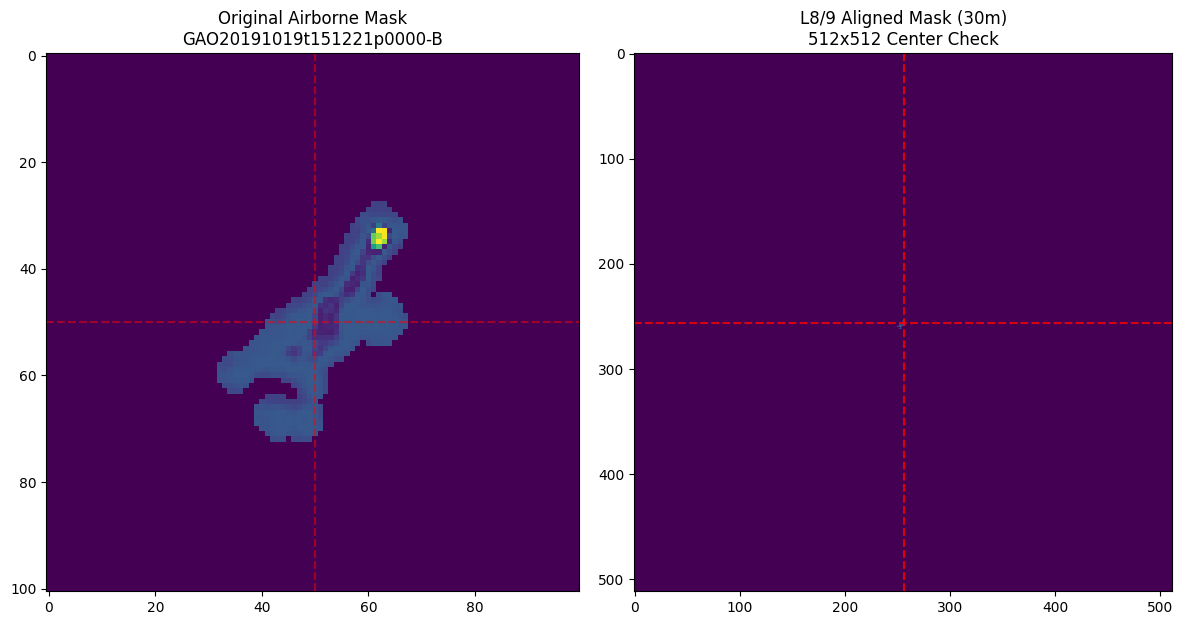

------------------------------
Processing: GAO20191019t151221p0000-C
Target (CSV) Center: Lat 31.423484, Lon -101.55237
Original Mask Center:  (31.422634184369734, -101.55232851151438)
30m Resized Center:    (31.423473462302717, -101.55236084783219)
Shift from Target:     ~1.17m Lat, ~0.87m Lon


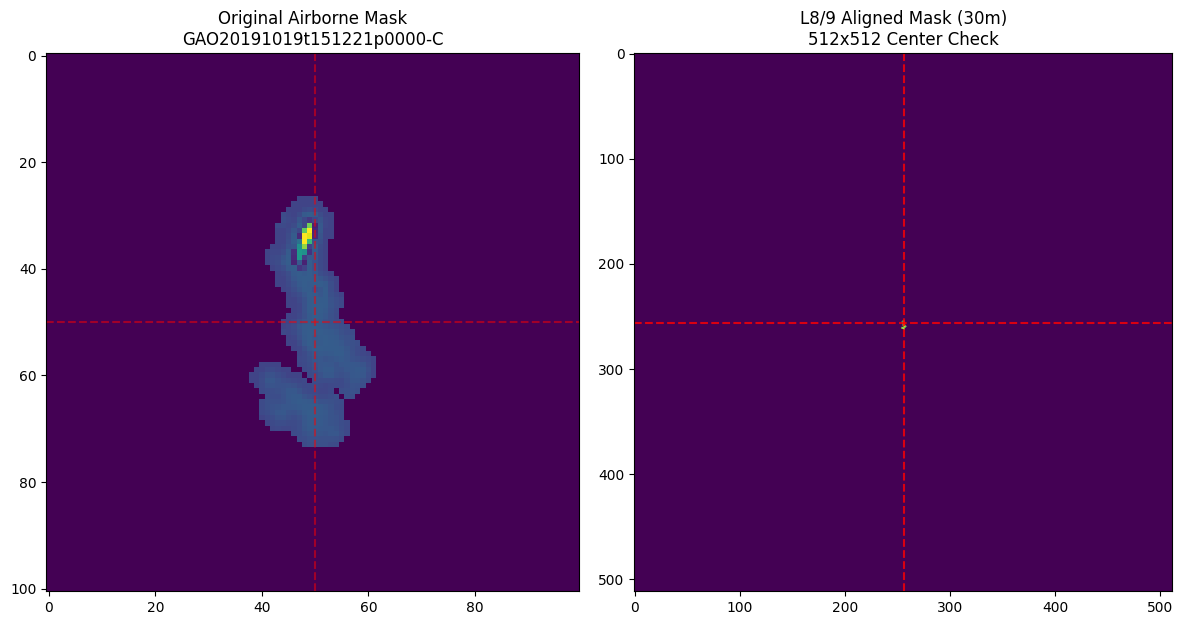

------------------------------
Processing: GAO20191019t152720p0000-A
Target (CSV) Center: Lat 31.39041, Lon -101.61676
Original Mask Center:  (31.3901046173016, -101.61644923388904)
30m Resized Center:    (31.39029875460415, -101.61663143674556)
Shift from Target:     ~12.35m Lat, ~12.18m Lon


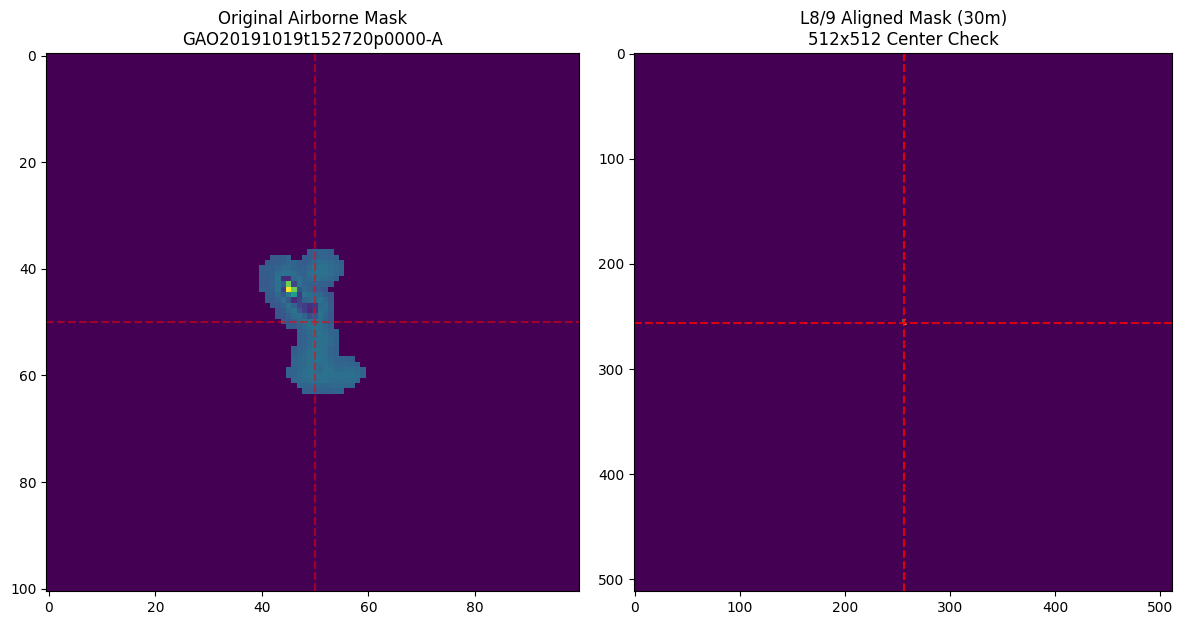

In [2]:
import pandas as pd
import os
import rasterio
from pyproj import Transformer
import matplotlib.pyplot as plt
import numpy as np

def get_center_latlon(tif_file):
    with rasterio.open(tif_file) as src:
        # Get the center pixel coordinates
        width = src.width
        height = src.height
        center_x = width / 2
        center_y = height / 2
        
        # Convert pixel coordinates to projection coordinates (UTM/etc)
        # Using the * operator with a tuple (x, y) returns the world coordinates
        center_world_x, center_world_y = src.transform * (center_x, center_y)
        
        # Create a transformer to convert from image CRS to WGS84 (Lat/Lon)
        # always_xy=True ensures output is (Lon, Lat)
        transformer = Transformer.from_crs(src.crs, "EPSG:4326", always_xy=True)
        center_lon, center_lat = transformer.transform(center_world_x, center_world_y)
        
        return center_lat, center_lon

# =========================
# Config for L8/9 Check
# =========================
# Path where you generated the new 30m masks
MASK_ROOT = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/plume_masks_l89_512'
# Original airborne mask directory
BASE_AIRBORNE_DIR = '/data2/yuyao/methane_emission/carbon_mapper_data_masks'
# Metadata CSV
CSV_PATH = '/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file.csv'

df = pd.read_csv(CSV_PATH)

count = 0
for index, row in df.iterrows():
    pid = row['plume_id']
    target_lat = row['plume_latitude']
    target_lon = row['plume_longitude']
    
    # Define paths
    input_tif = os.path.join(BASE_AIRBORNE_DIR, pid, 'plume.tif')
    resized_tif = os.path.join(MASK_ROOT, pid, 'mask_30m_512.tif')

    # Only process if both files exist
    if os.path.exists(input_tif) and os.path.exists(resized_tif):
        print("-" * 30)
        print(f"Processing: {pid}")
        print(f"Target (CSV) Center: Lat {target_lat}, Lon {target_lon}")

        try:
            # Get calculated centers
            center_input = get_center_latlon(input_tif)
            center_resized = get_center_latlon(resized_tif)

            print(f"Original Mask Center:  {center_input}")
            print(f"30m Resized Center:    {center_resized}")

            # Calculate shift in meters (approximate)
            lat_diff = abs(center_resized[0] - target_lat) * 111000
            lon_diff = abs(center_resized[1] - target_lon) * 111000 * np.cos(np.radians(target_lat))
            print(f"Shift from Target:     ~{lat_diff:.2f}m Lat, ~{lon_diff:.2f}m Lon")

            # Plotting
            with rasterio.open(input_tif) as s1:
                img1 = s1.read(1)
            with rasterio.open(resized_tif) as s2:
                img2 = s2.read(1)

            fig, axes = plt.subplots(1, 2, figsize=(12, 6))

            # Original Image
            axes[0].imshow(img1, cmap='viridis')
            axes[0].set_title(f'Original Airborne Mask\n{pid}')
            axes[0].axhline(img1.shape[0]//2, color='red', linestyle='--', alpha=0.5)
            axes[0].axvline(img1.shape[1]//2, color='red', linestyle='--', alpha=0.5)

            # Resized/Aligned Image
            axes[1].imshow(img2, cmap='viridis')
            axes[1].set_title(f'L8/9 Aligned Mask (30m)\n512x512 Center Check')
            # Add crosshairs to verify the mask is centered in the 512x512 window
            axes[1].axhline(256, color='red', linestyle='--', alpha=0.8)
            axes[1].axvline(256, color='red', linestyle='--', alpha=0.8)

            plt.tight_layout()
            plt.show()

            count += 1
            if count >= 5: # Just check 5 samples
                break
                
        except Exception as e:
            print(f"Error checking {pid}: {e}")

----------------------------------------
Processing Plume: GAO20191022t151126p0000-D
Landsat Shape: (512, 512) | Mask Shape: (512, 512)


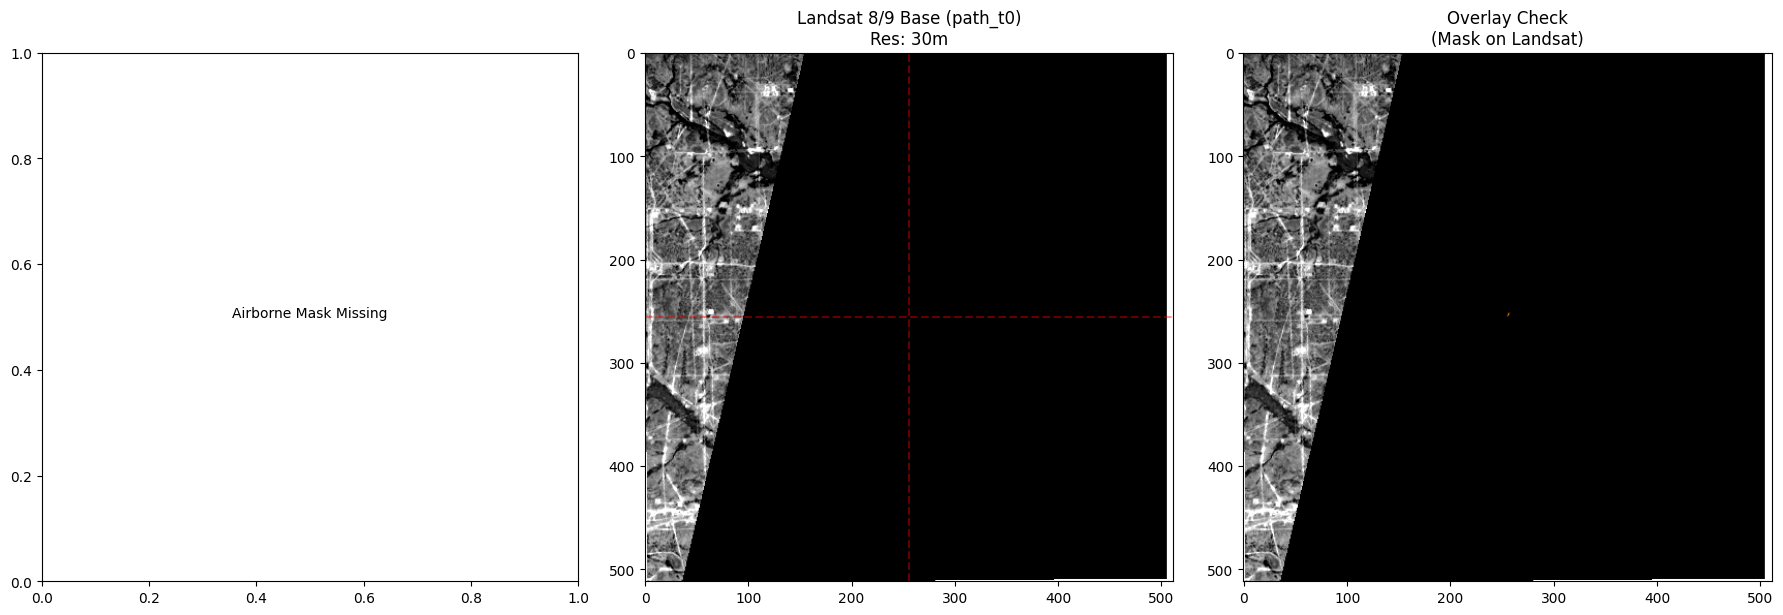

----------------------------------------
Processing Plume: GAO20191022t151126p0000-F
Landsat Shape: (512, 512) | Mask Shape: (512, 512)


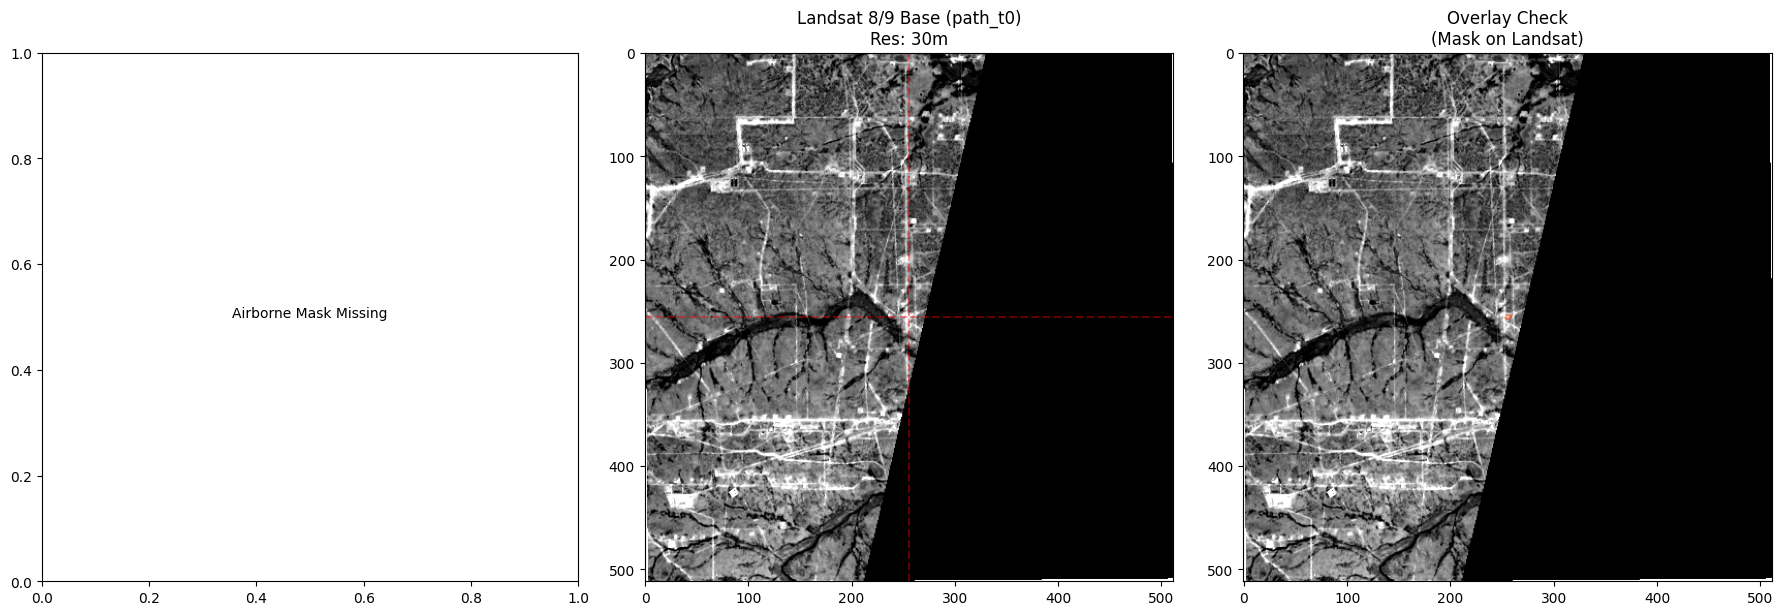

----------------------------------------
Processing Plume: GAO20191022t151126p0000-G
Landsat Shape: (512, 512) | Mask Shape: (512, 512)


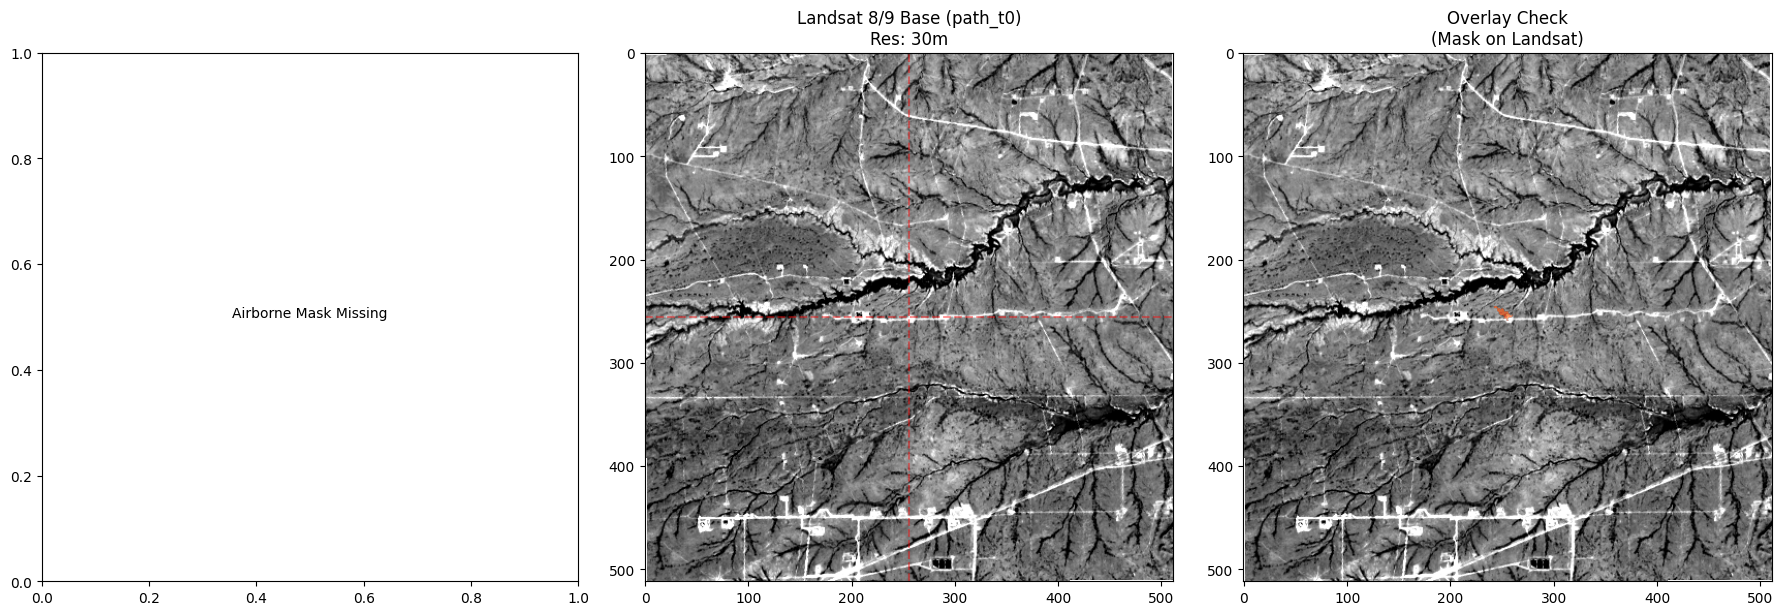

----------------------------------------
Processing Plume: GAO20191022t151126p0000-H
Landsat Shape: (512, 512) | Mask Shape: (512, 512)


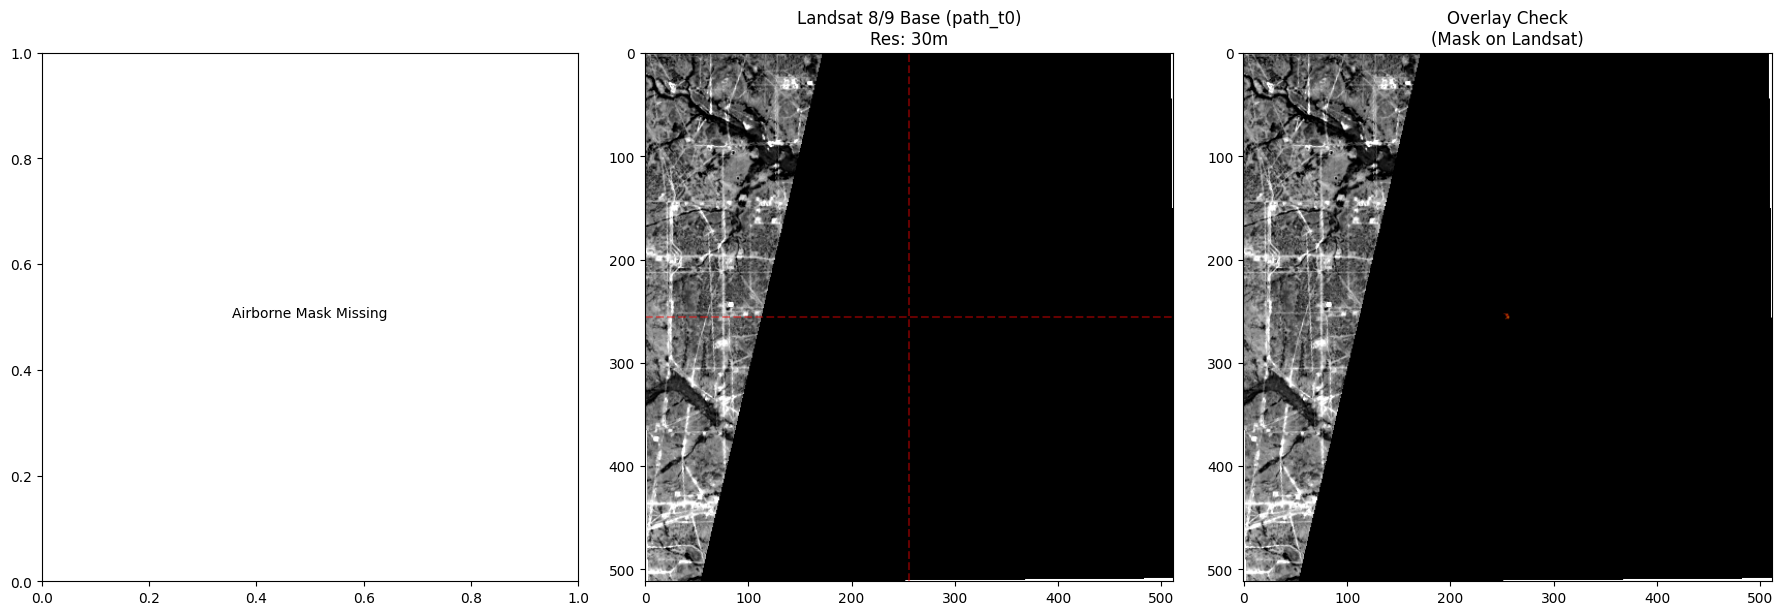

----------------------------------------
Processing Plume: GAO20191022t154327p0000-E
Landsat Shape: (512, 512) | Mask Shape: (512, 512)


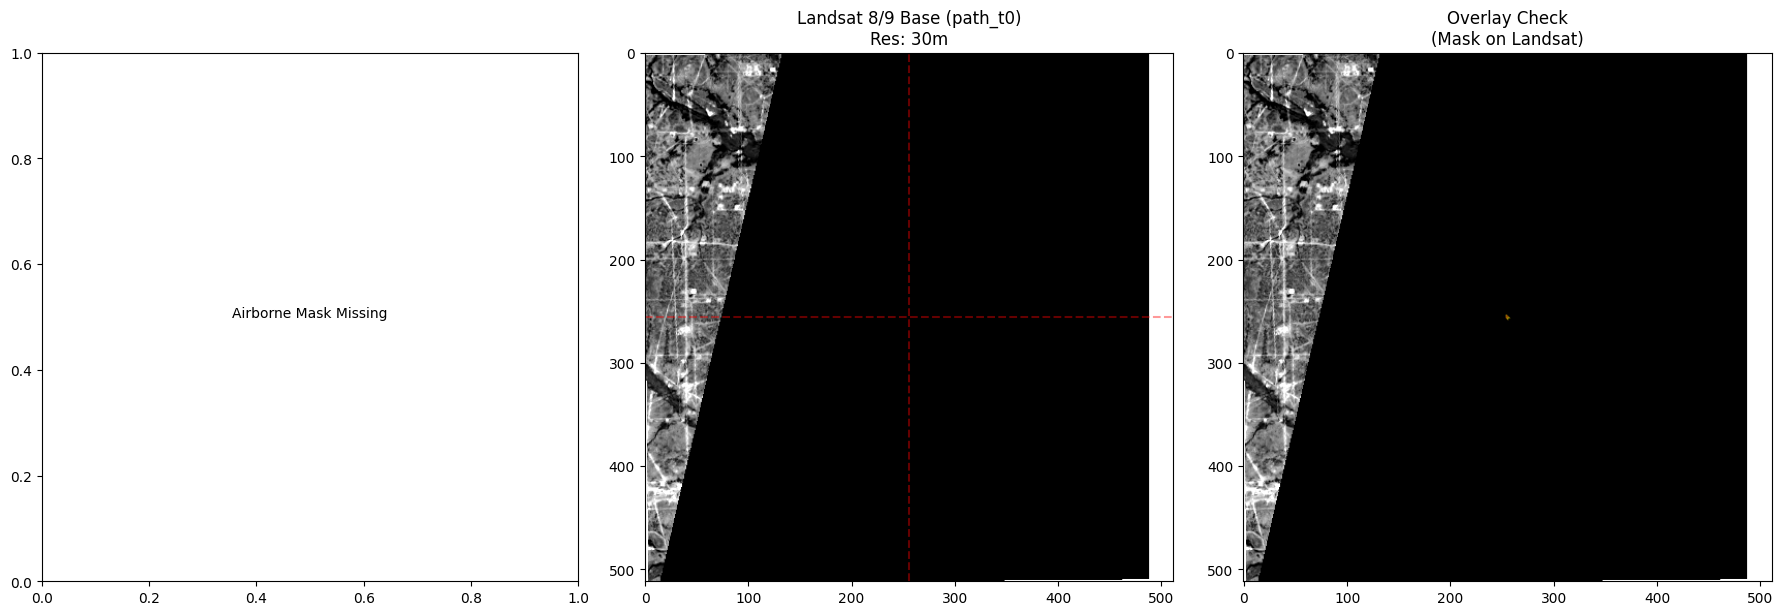

In [13]:
import pandas as pd
import os
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from pyproj import Transformer

# =========================
# 路径配置
# =========================
# 包含 path_t0 等路径的新 CSV 文件
CSV_PATH = '/home/yuyao/methane_train/preprocess_dataset_L89/CM_L89_L2SR_std512.csv' 
# 处理后的 30m 掩膜根目录
MASK_ROOT = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/plume_masks_l89_512'
# 原始高分辨率航空掩膜根目录
BASE_AIRBORNE_DIR = '/data2/yuyao/methane_emission/carbon_mapper_data_masks'

def load_and_preprocess_landsat(path):
    """读取 Landsat 影像并进行鲁棒性归一化"""
    if not os.path.exists(path):
        return None
    with rasterio.open(path) as src:
        # 读取第一波段
        data = src.read(1).astype(float)
        
        # 排除无效值 (通常为 0 或 -9999)
        valid_mask = data > 0
        if not np.any(valid_mask):
            return np.zeros_like(data)
        
        # 使用 2% 和 98% 分位数拉伸对比度，防止全白
        vmin, vmax = np.percentile(data[valid_mask], [2, 98])
        data_clipped = np.clip(data, vmin, vmax)
        data_norm = (data_clipped - vmin) / (vmax - vmin + 1e-6)
        return data_norm

def get_data(path):
    """通用读取单波段数据"""
    if os.path.exists(path):
        with rasterio.open(path) as src:
            return src.read(1)
    return None

# 读取数据
df = pd.read_csv(CSV_PATH)
count = 0

for index, row in df.iterrows():
    pid = row['plume_id']
    l89_t0_path = row['l89_0_std_512']
    
    # 路径构建
    airborne_mask_path = os.path.join(BASE_AIRBORNE_DIR, pid, 'plume.tif')
    resized_mask_path = os.path.join(MASK_ROOT, pid, 'mask_30m_512.tif')

    # 读取三方数据
    img_airborne = get_data(airborne_mask_path)
    img_resized = get_data(resized_mask_path)
    img_landsat = load_and_preprocess_landsat(l89_t0_path)

    # 如果关键数据缺失，跳过
    if img_landsat is None:
        print(f"Skipping {pid}: Landsat image not found at {l89_t0_path}")
        continue

    print("-" * 40)
    print(f"Processing Plume: {pid}")
    print(f"Landsat Shape: {img_landsat.shape} | Mask Shape: {img_resized.shape if img_resized is not None else 'N/A'}")

    # 开始绘图
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 图1: 原始航空掩膜 (验证数据源)
    if img_airborne is not None:
        axes[0].imshow(img_airborne, cmap='viridis')
        axes[0].set_title(f"Original Airborne Mask\n{pid}")
    else:
        axes[0].text(0.5, 0.5, 'Airborne Mask Missing', ha='center')

    # 图2: Landsat 8/9 真实底图 (验证底图是否正确读取)
    axes[1].imshow(img_landsat, cmap='gray')
    axes[1].set_title(f"Landsat 8/9 Base (path_t0)\nRes: 30m")
    # 画中心十字线
    axes[1].axhline(img_landsat.shape[0]//2, color='red', linestyle='--', alpha=0.4)
    axes[1].axvline(img_landsat.shape[1]//2, color='red', linestyle='--', alpha=0.4)

    # 图3: 叠加显示 (验证掩膜位置)
    axes[2].imshow(img_landsat, cmap='gray')
    if img_resized is not None:
        # 如果尺寸不一致，强制缩放到卫星图尺寸以便叠加显示
        if img_resized.shape != img_landsat.shape:
            from skimage.transform import resize
            img_resized_disp = resize(img_resized, img_landsat.shape, order=0, preserve_range=True)
        else:
            img_resized_disp = img_resized
            
        # 仅显示非零区域（掩膜部分）
        masked_data = np.ma.masked_where(img_resized_disp == 0, img_resized_disp)
        axes[2].imshow(masked_data, cmap='autumn', alpha=0.6) # 红色/橙色显示掩膜
        axes[2].set_title("Overlay Check\n(Mask on Landsat)")
    else:
        axes[2].set_title("Resized Mask Missing")

    plt.tight_layout()
    plt.show()

    count += 1
    if count >= 5: # 仅检查前5个样本
        break

In [8]:
import pandas as pd
import os

# Paths
CSV_PATH = "./CM_L89_L2SR_std512.csv"
MASK_ROOT = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/plume_masks_l89_512"

df = pd.read_csv(CSV_PATH)

def get_mask_path(pid):
    # This matches the structure: /MASK_ROOT/plume_id/mask_30m_512.tif
    path = os.path.join(MASK_ROOT, str(pid), 'mask_30m_512.tif')
    return path if os.path.exists(path) else None

print("Updating mask paths...")
df['mask_path'] = df['plume_id'].apply(get_mask_path)

# Check for missing masks
missing_count = df['mask_path'].isna().sum()
if missing_count > 0:
    print(f"Warning: {missing_count} plumes do not have a mask file in {MASK_ROOT}")

df.to_csv(CSV_PATH, index=False)
print("CSV updated successfully.")

Updating mask paths...
CSV updated successfully.


In [3]:
import tifffile
import numpy as np
import pandas as pd

df = pd.read_csv("./CM_L89_L2SR_std512.csv")
sample_path = df['l89_0_std_512'].iloc[0]
img = tifffile.imread(sample_path)

print(f"Min value: {np.nanmin(img)}")
print(f"Max value: {np.nanmax(img)}")
print(f"Number of NaNs: {np.isnan(img).sum()}")
print(f"Number of Zeros: {(img == 0).sum()}")

Min value: 0.0
Max value: 65454.0
Number of NaNs: 46140
Number of Zeros: 1932189


In [8]:
import pandas as pd
import os

# Paths
MANIFEST_PATH = "./CM_L89_L2SR_std512.csv"
METADATA_PATH = "/home/yuyao/methane_train/csvs/merged_file.csv"

# 1. Load the files
print("Loading data...")
manifest_df = pd.read_csv(MANIFEST_PATH)
metadata_df = pd.read_csv(METADATA_PATH)

# 2. Extract only necessary columns from metadata to avoid clutter
# We use plume_id as the key and datetime as the value to add
metadata_subset = metadata_df[['plume_id', 'datetime', "plume_latitude", "plume_longitude"]].drop_duplicates(subset=['plume_id'])

# 3. Merge (Join) on plume_id
# 'how='left' ensures we keep all rows in your manifest even if metadata is missing
updated_df = manifest_df.merge(metadata_subset, on='plume_id', how='left')

# 4. Verification
missing_dates = updated_df['datetime'].isna().sum()
if missing_dates > 0:
    print(f"Warning: {missing_dates} rows could not find a matching datetime for their plume_id.")
else:
    print("Success: All rows matched with a datetime.")

# 5. Save the updated manifest back to the same location
updated_df.to_csv(MANIFEST_PATH, index=False)
print(f"Updated manifest saved to {MANIFEST_PATH}")

# Show a quick preview
print(updated_df.head())

Loading data...
Success: All rows matched with a datetime.
Updated manifest saved to ./CM_L89_L2SR_std512.csv
                    plume_id  \
0  GAO20191022t151126p0000-D   
1  GAO20191022t151126p0000-F   
2  GAO20191022t151126p0000-G   
3  GAO20191022t151126p0000-H   
4  GAO20191022t154327p0000-E   

                                            l89_path  \
0  /mnt/engg-leung/Research_No9_Methane_Emissions...   
1  /mnt/engg-leung/Research_No9_Methane_Emissions...   
2  /mnt/engg-leung/Research_No9_Methane_Emissions...   
3  /mnt/engg-leung/Research_No9_Methane_Emissions...   
4  /mnt/engg-leung/Research_No9_Methane_Emissions...   

                                         l89_-7_path  \
0  /mnt/engg-leung/Research_No9_Methane_Emissions...   
1  /mnt/engg-leung/Research_No9_Methane_Emissions...   
2  /mnt/engg-leung/Research_No9_Methane_Emissions...   
3  /mnt/engg-leung/Research_No9_Methane_Emissions...   
4  /mnt/engg-leung/Research_No9_Methane_Emissions...   

                       

In [1]:
import os
import pandas as pd
import numpy as np
import tifffile
import random
import torch
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import threading

# =========================
# Config
# =========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_DIR = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224_updated"
INPUT_CSV = "./CM_L89_L2SR_std512.csv"

OS_SIZE = 32
TARGET_SIZE = 224
CENTER_BOX = 6
MISSING_THRESH = 0.25
N_POS, N_NEG = 16, 16
NUM_WORKERS = 8  # Increase this to speed up remote disk reading

os.makedirs(BASE_DIR, exist_ok=True)
counter_lock = threading.Lock()
global_cnt = 0
visual_done = 0

# =========================
# GPU & Format Helpers
# =========================

def ensure_chw(img):
    if img.ndim == 2: return img[np.newaxis, ...]
    if img.ndim == 3 and img.shape[0] > 100: return img.transpose(2, 0, 1)
    return img

def gpu_upsample(crop_np):
    """Safe GPU upsampling."""
    with torch.no_grad():
        img_t = torch.from_numpy(crop_np.astype(np.float32)).to(DEVICE).unsqueeze(0)
        img_t = torch.nan_to_num(img_t, nan=0.0)
        upsampled = F.interpolate(img_t, size=(TARGET_SIZE, TARGET_SIZE), mode='bilinear', align_corners=False)
        return upsampled.squeeze(0).cpu().numpy()

# =========================
# Worker Function (Modified)
# =========================

def process_single_row(row):
    global global_cnt, visual_done
    local_results = []
    
    try:
        # 读取原始时序数据
        t0 = ensure_chw(tifffile.imread(row["l89_0_std_512"]))
        t1 = ensure_chw(tifffile.imread(row["l89_-90_std_512"]))
        t2 = ensure_chw(tifffile.imread(row["l89_-360_std_512"]))
        full_mask = tifffile.imread(row["mask_path"])
    except Exception as e:
        return []

    # 辅助函数：检查切片是否有效（无缺失像素）
    def is_valid_crop(crop):
        if crop.size == 0: return False
        return (np.isnan(crop[0]) | (crop[0] == 0)).mean() <= MISSING_THRESH

    # --- POSITIVE SAMPLES ---
    p_start_min = 256 + (CENTER_BOX // 2) - OS_SIZE
    p_start_max = 256 - (CENTER_BOX // 2)
    pos_count, attempts = 0, 0
    
    while pos_count < N_POS and attempts < 100:
        attempts += 1
        x, y = random.randint(p_start_min, p_start_max), random.randint(p_start_min, p_start_max)
        c0, c1, c2 = t0[:, y:y+OS_SIZE, x:x+OS_SIZE], t1[:, y:y+OS_SIZE, x:x+OS_SIZE], t2[:, y:y+OS_SIZE, x:x+OS_SIZE]
        
        # 正样本必须保证三个时段都相对完整
        if not (is_valid_crop(c0) and is_valid_crop(c1) and is_valid_crop(c2)):
            continue
            
        m_crop = full_mask[y:y+OS_SIZE, x:x+OS_SIZE]
        up0, up1, up2 = gpu_upsample(c0), gpu_upsample(c1), gpu_upsample(c2)
        m_up = np.repeat(np.repeat(m_crop, 7, axis=0), 7, axis=1)

        with counter_lock:
            global_cnt += 1
            this_id = global_cnt

        out_path = os.path.join(BASE_DIR, str(this_id))
        os.makedirs(out_path, exist_ok=True)
        
        # 物理保存文件
        p0, p90, p360 = os.path.join(out_path, "l89_0.tif"), os.path.join(out_path, "l89_90.tif"), os.path.join(out_path, "l89_360.tif")
        tifffile.imwrite(p0, up0); tifffile.imwrite(p90, up1); tifffile.imwrite(p360, up2)
        tifffile.imwrite(os.path.join(out_path, "plume.tif"), m_up)

        local_results.append({
            "id": this_id, "label": 1, "plume_id": row["plume_id"], "path": out_path,
            "path_t0": p0, "path_t90": p90, "path_t360": p360,
            "latitude": row["plume_latitude"], "longitude": row["plume_longitude"]
        })
        pos_count += 1

    # --- NEGATIVE SAMPLES ---
    neg_count, attempts = 0, 0
    while neg_count < N_NEG and attempts < 200: # 负样本不合格时通过循环重新 Crop
        attempts += 1
        x, y = random.randint(0, 512-OS_SIZE), random.randint(0, 512-OS_SIZE)
        if (x <= 256 <= x+OS_SIZE) and (y <= 256 <= y+OS_SIZE): continue

        c0, c1, c2 = t0[:, y:y+OS_SIZE, x:x+OS_SIZE], t1[:, y:y+OS_SIZE, x:x+OS_SIZE], t2[:, y:y+OS_SIZE, x:x+OS_SIZE]
        
        # 关键改进：如果负样本时序不全，重新采样
        if not (is_valid_crop(c0) and is_valid_crop(c1) and is_valid_crop(c2)):
            continue

        up0, up1, up2 = gpu_upsample(c0), gpu_upsample(c1), gpu_upsample(c2)
        
        with counter_lock:
            global_cnt += 1
            this_id = global_cnt

        out_path = os.path.join(BASE_DIR, str(this_id))
        os.makedirs(out_path, exist_ok=True)
        
        p0, p90, p360 = os.path.join(out_path, "l89_0.tif"), os.path.join(out_path, "l89_90.tif"), os.path.join(out_path, "l89_360.tif")
        tifffile.imwrite(p0, up0); tifffile.imwrite(p90, up1); tifffile.imwrite(p360, up2)
        tifffile.imwrite(os.path.join(out_path, "plume.tif"), np.zeros((224, 224), dtype='uint8'))
        
        local_results.append({
            "id": this_id, "label": 0, "plume_id": row["plume_id"], "path": out_path,
            "path_t0": p0, "path_t90": p90, "path_t360": p360,
            "latitude": row["plume_latitude"], "longitude": row["plume_longitude"]
        })
        neg_count += 1

    return local_results

def save_visual_check(idx, t0, t0_up, mask, mask_up):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(t0[0], cmap='viridis'); axes[0].set_title("32x32 Raw")
    axes[1].imshow(t0_up[0], cmap='viridis'); axes[1].set_title("224x224 Up")
    axes[2].imshow(mask, cmap='gray'); axes[3].imshow(mask_up, cmap='gray')
    plt.savefig(os.path.join(BASE_DIR, f"check_{idx}.png"))
    plt.close()

# =========================
# Main execution
# =========================
def get_start_cnt(base_dir):
    """检查已经生成的文件夹，防止覆盖"""
    existing_ids = [int(d) for d in os.listdir(base_dir) if d.isdigit()]
    return max(existing_ids) if existing_ids else 0

# 在执行前初始化
os.makedirs(BASE_DIR, exist_ok=True)
global_cnt = get_start_cnt(BASE_DIR)
print(f"Current max ID in storage: {global_cnt}. New samples will start from {global_cnt + 1}")

counter_lock = threading.Lock()
visual_done = 0 # 视觉检查可以重新生成

# =========================
# 修改后的主执行函数
# =========================
def process_all():
    global global_cnt
    
    # 1. 读取输入并加载已有的 manifest (如果存在)
    df = pd.read_csv(INPUT_CSV).dropna(subset=['mask_path'])
    manifest_path = os.path.join(BASE_DIR, "dataset_manifest.csv")
    
    processed_plume_ids = set()
    all_data = []

    if os.path.exists(manifest_path):
        try:
            old_df = pd.read_csv(manifest_path)
            all_data = old_df.to_dict('records')
            processed_plume_ids = set(old_df['plume_id'].unique())
            print(f"Resuming: {len(processed_plume_ids)} plume_ids already processed.")
        except:
            print("Manifest exists but could not be read. Starting fresh.")

    # 2. 过滤掉已经处理过的 plume_id
    df_to_process = df[~df['plume_id'].isin(processed_plume_ids)]
    
    if len(df_to_process) == 0:
        print("All rows already processed!")
        return

    print(f"Remaining rows to process: {len(df_to_process)}")

    # 3. 并行处理
    with ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
        rows = [row for _, row in df_to_process.iterrows()]
        
        # 使用 as_completed 或简单的循环来实时获取结果
        pbar = tqdm(total=len(rows))
        for res_list in executor.map(process_single_row, rows):
            if res_list:
                all_data.extend(res_list)
            
            pbar.update(1)
            
            # 每处理 50 个原始行，强制存一次盘，防止崩溃
            if pbar.n % 50 == 0:
                pd.DataFrame(all_data).to_csv(manifest_path, index=False)
    
    # 最后存一次全量数据
    final_df = pd.DataFrame(all_data)
    final_df.to_csv(manifest_path, index=False)
    print(f"Finished. Total samples in manifest: {len(final_df)}")

if __name__ == "__main__":
    process_all()

Current max ID in storage: 54390. New samples will start from 54391
Remaining rows to process: 2603


  4%|▍         | 100/2603 [05:11<2:35:16,  3.72s/it]

KeyboardInterrupt: 

In [11]:
import pandas as pd
# INPUT_CSV = "./CM_L89_L2SR_std512.csv"
# df1 = pd.read_csv(INPUT_CSV)
# df1 = df1[['plume_id', 'datetime']].drop_duplicates(subset=['plume_id'])

# df = pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224_updated/dataset_manifest.csv")
# df2 = df.merge(df1, on='plume_id', how='left')

# # 4. Verification
# missing_dates = df2['datetime'].isna().sum()
# if missing_dates > 0:
#     print(f"Warning: {missing_dates} rows could not find a matching datetime for their plume_id.")
# else:
#     print("Success: All rows matched with a datetime.")
# # 5. Save the updated manifest back to the same location
# df2.to_csv('/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224_updated/dataset_manifest.csv', index=False)
# # Show a quick preview

# df=df2
df = pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224_updated/dataset_manifest.csv")
# print(df2.head())
# df2['date'] = pd.to_datetime(df2['datetime'])
# train_df = df[(df['date'] < '2024-04-10') | (df['date'] >= '2025-01-01')]  # 2025-04-01
# test_df = df[(df['date'] >= '2024-04-10') & (df['date'] < '2025-01-01')]
# train_df = df[(df['datetime'] < '2024-07-10')]  # 2025-04-01
# test_df = df[(df['datetime'] >= '2024-07-10') & (df['datetime'] <= '2024-12-31')]
train_df = df[(df['datetime'] < '2025-05-20')]  # 2025-04-01
test_df = df[(df['datetime'] >= '2025-05-20')]
print(f'training set {len(train_df)} testing set {len(test_df)} train ratio {len(train_df)/(len(train_df)+len(test_df)):.3f}')

train_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224_updated/train_2025.csv'
train_df.to_csv(train_csv, index=False)
print(f'train set size {len(train_df)}')

test_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/data_dir_l89_L2SR/l89_temporal_32_resized_to_224_updated/test_2025.csv'
test_df.to_csv(test_csv, index=False)
print(f'test set size {len(test_df)}')


training set 55532 testing set 11996 train ratio 0.822
train set size 55532
test set size 11996
